In [71]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score


In [72]:
df = pd.read_csv("housing_india_data.csv")
df.head()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
1,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
2,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
3,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
4,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,...,1951,0,122007,52.9133,-114.590,2380,4750,1,67,790000


In [73]:
df.drop(columns=['id', 'Date'], inplace = True)

In [74]:
X = df.iloc[:,:-1]
y = df.iloc[:, -1]
print(X.shape)
print(y.shape)


(14619, 20)
(14619,)


In [75]:
X.insert(0, "Zero Column", 1)

In [76]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=69)

In [77]:
Xtrain.head()

,Zero Column,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,grade of the house,...,Area of the basement,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport
6732,1,3,3.25,2210,3600,2.0,0,0,3,8,...,390,1995,0,122022,52.9331,-114.469,2010,6690,1,58
13056,1,4,2.00,2760,27631,2.0,0,0,4,8,...,960,1978,0,122014,52.9784,-114.481,2490,13158,3,75
984,1,3,2.50,1270,9675,2.0,0,0,3,8,...,0,1993,0,122025,52.6939,-113.934,1270,11700,3,66
14049,1,4,1.75,2040,6000,1.0,0,0,5,7,...,1020,1943,0,122016,52.7807,-114.573,1440,6000,1,77
3673,1,4,1.75,2085,174240,1.0,0,0,3,7,...,475,1964,0,122036,52.8053,-114.140,2690,174240,2,72


In [78]:
Xtrain_T = Xtrain.T

In [79]:
theta = np.linalg.solve(Xtrain_T @ Xtrain, Xtrain_T @ ytrain)

In [80]:
print(theta.shape)

(21,)


In [81]:
ypred = Xtest @ theta

In [82]:
print(ypred)

4411     5.391217e+05
6708     5.564333e+05
13972    5.563104e+05
2484     2.513856e+05
466      3.671620e+05
             ...     
11902    4.587008e+05
10043    4.242862e+05
888      4.058204e+05
13488    1.537164e+06
8381     8.078474e+05
Length: 4386, dtype: float64


In [83]:
ypred

,0
4411,5.391217e+05
6708,5.564333e+05
13972,5.563104e+05
2484,2.513856e+05
466,3.671620e+05
...,...
11902,4.587008e+05
10043,4.242862e+05
888,4.058204e+05
13488,1.537164e+06


In [84]:
rmse = np.sqrt(np.mean((ytest - ypred)**2))
r2 = r2_score(ytest, ypred)
mse = np.mean((ytest - ypred)**2)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 36595985185.62574
RMSE: 191300.77152386433
R²: 0.7067041942561396


In [85]:
# Using functions
mse = mean_squared_error(ytest, ypred)
rmse = np.sqrt(mse)
r2 = r2_score(ytest, ypred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R^2:", r2)


MSE: 36595985185.62574
RMSE: 191300.77152386433
R^2: 0.7067041942561396


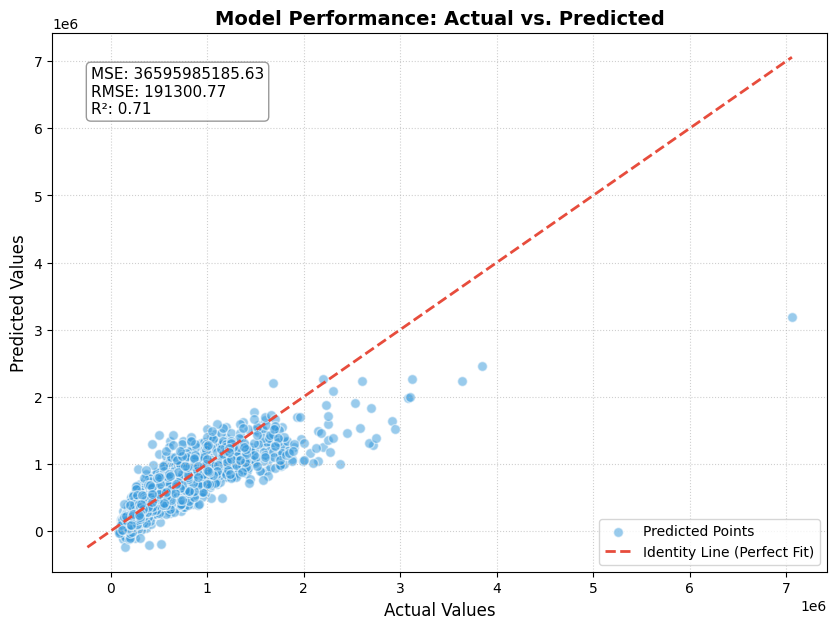

In [86]:
plt.figure(figsize=(10, 7))
plt.scatter(ytest, ypred, alpha=0.5, color='#3498db', edgecolors='white', s=50, label='Predicted Points')

limit_min = min(ytest.min(), ypred.min())
limit_max = max(ytest.max(), ypred.max())
plt.plot([limit_min, limit_max], [limit_min, limit_max], color='#e74c3c', linestyle='--', linewidth=2, label='Identity Line (Perfect Fit)')

plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.title('Model Performance: Actual vs. Predicted', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)

stats_text = f'MSE: {mse:.2f}\nRMSE: {rmse:.2f}\nR²: {r2:.2f}'
plt.annotate(stats_text, xy=(0.05, 0.85), xycoords='axes fraction',
             bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8), fontsize=11)

plt.legend(loc='lower right')
plt.show()

In [87]:
# Multi Linear Regression #

In [88]:
Xtrain.head()

,Zero Column,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,grade of the house,...,Area of the basement,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport
6732,1,3,3.25,2210,3600,2.0,0,0,3,8,...,390,1995,0,122022,52.9331,-114.469,2010,6690,1,58
13056,1,4,2.00,2760,27631,2.0,0,0,4,8,...,960,1978,0,122014,52.9784,-114.481,2490,13158,3,75
984,1,3,2.50,1270,9675,2.0,0,0,3,8,...,0,1993,0,122025,52.6939,-113.934,1270,11700,3,66
14049,1,4,1.75,2040,6000,1.0,0,0,5,7,...,1020,1943,0,122016,52.7807,-114.573,1440,6000,1,77
3673,1,4,1.75,2085,174240,1.0,0,0,3,7,...,475,1964,0,122036,52.8053,-114.140,2690,174240,2,72


In [89]:
Xtrain_T = Xtrain.T

In [90]:
theta = np.linalg.solve(Xtrain_T @ Xtrain, Xtrain_T @ ytrain)

In [91]:
theta.shape

(21,)

In [92]:
ypred = Xtest @ theta

In [93]:
rmse = np.sqrt(np.mean((ytest-ypred)**2))
r2 = r2_score(ytest, ypred)
mse = np.mean((ytest - ypred)**2)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("R^2: ", r2)

MSE:  36595985185.62574
RMSE:  191300.77152386433
R^2:  0.7067041942561396


In [94]:
# MLR Using functions
mse = mean_squared_error(ytest, ypred)
rmse = np.sqrt(mse)
r2 = r2_score(ytest, ypred)

print("MLR MSE:", mse)
print("MLR RMSE:", rmse)
print("MLR R^2:", r2)


MLR MSE: 36595985185.62574
MLR RMSE: 191300.77152386433
MLR R^2: 0.7067041942561396


MLR MSE: 36595985185.62574
MLR RMSE: 191300.77152386433
MLR R^2: 0.7067041942561396


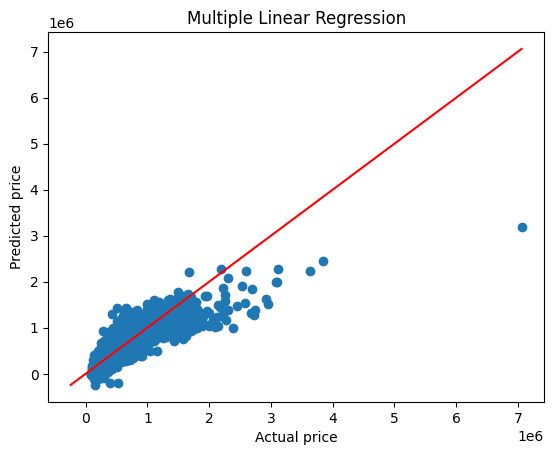

In [95]:
mse = mean_squared_error(ytest, ypred)
rmse = np.sqrt(mse)
r2 = r2_score(ytest, ypred)

print("MLR MSE:", mse)
print("MLR RMSE:", rmse)
print("MLR R^2:", r2)
plt.figure()
plt.scatter(ytest, ypred)
minVal = min(ytest.min(), ypred.min())
maxVal = max(ytest.max(), ypred.max())
plt.plot([minVal, maxVal], [minVal, maxVal], color= "red")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Multiple Linear Regression")
plt.show()